# Diagrammes binaires

Isobares

## Bibliothèques

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 
import matplotlib
import scipy.constants as cst
import scipy.optimize as opt
from matplotlib import ticker

matplotlib.rcParams.update({'font.size': 14})

## Introduction des variables

In [25]:
R = cst.R

Diagramme sans azéotrope ou hétéroazéotrope : éthanol/méthanol 

Diagramme azéotropique : éthanol/eau

Diagramme hétéroazéotropique : toluène/eau

In [30]:
T_eb_eau, Delta_h_vap_eau = 273.15 + 100, 40.7e3
T_eb_etoh, Delta_h_vap_etoh = 273.15 + 79, 38.8e3
T_eb_tol, Delta_h_vap_tol = 273.15 + 110.6, 33.2e3
T_eb_meoh, Delta_h_vap_meoh = 273.15 + 65, 35.2e3

"""
T_eb_X en K
Delta_h_vap_X en J/K/mol
"""

azeotrope, heteroazeotrope = False, True      # Choix du type de diagramme

if azeotrope and not heteroazeotrope :
    T_eb_1, Delta_h_vap_1 = T_eb_eau, Delta_h_vap_eau     # Eau 
    T_eb_2, Delta_h_vap_2 = T_eb_etoh, Delta_h_vap_etoh   # Ethanol
elif heteroazeotrope and not azeotrope :
    T_eb_1, Delta_h_vap_1 = T_eb_eau, Delta_h_vap_eau     # Eau
    T_eb_2, Delta_h_vap_2 = T_eb_tol, Delta_h_vap_tol     # Toluène
elif azeotrope and heteroazeotrope :
    print('Fais un effort...')
else : # ni azéotrope, ni hétéroazéotrope (idéal)
    T_eb_1, Delta_h_vap_1 = T_eb_meoh, Delta_h_vap_meoh   # Méthanol
    T_eb_2, Delta_h_vap_2 = T_eb_etoh, Delta_h_vap_etoh   # Ethanol
    

## Tracer du diagramme, simple fuseau

Définition du système

In [31]:
def equations_fuseau(v, T_eb_1, Delta_h_vap_1, T_eb_2, Delta_h_vap_2, T0):
    """
    Fonction qui prend en argument les variables qu'on cherche à résoudre, les données du problème (températures d'ébulition, 
    enthalpies de vaporisation et T0 qui permetra de ballayer les températures) et qui renvoie un vecteur de dimension (1,5) 
    contenant les 5 équations couplées.
    
    v : liste - shape.v = 5, v = [x_1, x_2, y_1, y_2, T]
    T0 : float - valeur de T pour calculer x_1, ...
    """
    x_1, x_2, y_1, y_2, T = v
    # x : fraction molaire en liquide 
    # y : fraction molaire en vapeur 
    
    eq1 = y_1 - x_1 * np.exp(Delta_h_vap_1/R * (1/T_eb_1 - 1/T))
    eq2 = y_2 - x_2 * np.exp(Delta_h_vap_2/R * (1/T_eb_2 - 1/T))
    eq3 = x_1 + x_2 - 1
    eq4 = y_1 + y_2 - 1
    eq5 = T - T0 # besoin d'une 5e équation
    
    # print(np.shape(eq1), np.shape(eq2), np.shape(eq3), np.shape(eq4), np.shape(eq5))
    return np.array([eq1, eq2, eq3, eq4, eq5], dtype = float)

Résolution

In [32]:
if not azeotrope and not heteroazeotrope :
    etat_initial = (1, 0, 1, 0, T_eb_1)
    tab_T0 = np.linspace(T_eb_1, T_eb_2, 1000) # ensemble des T0 à parcourir
    # T0 = (T_eb_1 + T_eb_2) / 2
    resultats = []
    for T0 in tab_T0 : # boucle sur les valeurs de T0, pour obtenir tous les couples pour le diagramme
        solution = scipy.optimize.root(equations_fuseau, etat_initial, args = (T_eb_1, Delta_h_vap_1, T_eb_2, Delta_h_vap_2, T0))
        resultats.append(solution.x)
        etat_initial = solution.x

    # print(solutions.x)
    resultats = np.array(resultats)
    # print(resultats)

Tracer du diagramme 

In [33]:
if not azeotrope and not heteroazeotrope :
    x_1 = resultats[:,0]
    x_2 = resultats[:,1]
    y_1 = resultats[:,2]
    y_2 = resultats[:,3]
    T = resultats[:,4]

    fig, ax1 = plt.subplots(figsize = (12,9))
    ax2 = ax1.twinx()

    ax1.plot(x_1,T, c = 'cornflowerblue', label = "Courbe d'ébullition")
    ax2.plot(y_1,T, c = 'crimson', label = 'Courbe de rosée')
    ax1.grid(which = 'both', ls = ':')
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.set_xlim(0,1)
    ax1.set_xlabel(r'$x_{MeOH}$')
    ax1.set_ylabel('T (en K)')
    ax2.set_ylabel('T (en K)')
    ax1.set_title("Diagramme binaire liquide/vapeur du mélange MeOH/EtOH")
    plt.figlegend(["Courbe d'ébullition", 'Courbe de rosée'], bbox_to_anchor = (0.85,0.8))
    
    plt.text(0.1, 340, 'Liquide')
    plt.text(0.6, 348, 'Vapeur')
    plt.text(0.41, 346, 'L + V')

    plt.show()

## Tracer du diagramme, hétéroazéotrope

Définition du système

In [34]:
def equations_heteroazeotrope(v, bool1, T_eb_1, Delta_h_vap_1, T_eb_2, Delta_h_vap_2, T0):
    """
    Fonction qui prend en argument les variables qu'on cherche à résoudre, un bouléen de conditionnement, les données du 
    problème (températures d'ébulition, enthalpies de vaporisation et T0 qui permetra de ballayer les températures) et 
    qui renvoie un vecteur de dimension (1,3) contenant les 3 équations couplées.
    
    v : liste - shape.v = 3, v = [y_1, y_2, T]
    bool1 : booléen - True si on cherche y_1, False si on cherche y_2
    T0 : float - valeur de T pour calculer y_1, y_2
    """
    y_1, y_2, T = v
    # y : fraction molaire en vapeur 
    
    eq1 = y_1 - np.exp(Delta_h_vap_1/R * (1/T_eb_1 - 1/T))
    eq2 = y_2 - np.exp(Delta_h_vap_2/R * (1/T_eb_2 - 1/T))
    eq3 = y_2 + y_1 - 1 
    eq4 = T - T0
    
    # print(np.shape(eq1), np.shape(eq2), np.shape(eq3), np.shape(eq4), np.shape(eq5))
    if bool1 :
        return np.array([eq1, eq3, eq4], dtype = float)
    else :
        return np.array([eq2, eq3, eq4], dtype = float)

Résolution

In [35]:
if heteroazeotrope :
    etat_initial_1 = (1, 0, T_eb_1)
    etat_initial_2 = (1, 0, T_eb_1)
    tab_T0 = np.linspace(350, T_eb_2, 1000) # ensemble des T0 à parcourir
    #T0 = (T_eb_1 + T_eb_2) / 2
    resultats_1, resultats_2 = [], [] # Avant et après l'hétéroazéotrope 
    
    for T0 in tab_T0 : # boucle sur les valeurs de T0, pour obtenir tous les couples pour le diagramme
        solution_1 = scipy.optimize.root(equations_heteroazeotrope, etat_initial_1, 
                                       args = (True, T_eb_1, Delta_h_vap_1, T_eb_2, Delta_h_vap_2, T0))
        # print(solution.x)
        resultats_1.append(solution_1.x)
        etat_initial_1 = solution_1.x # réinitialisation de l'état initial
        
        solution_2 = scipy.optimize.root(equations_heteroazeotrope, etat_initial_2, 
                                       args = (False, T_eb_1, Delta_h_vap_1, T_eb_2, Delta_h_vap_2, T0))
        # print(solution.x)
        resultats_2.append(solution_2.x)
        etat_initial_2 = solution_2.x # réinitialisation de l'état initial

    # print(solutions.x)
    resultats_1, resultats_2 = np.array(resultats_1), np.array(resultats_2)
    resultats = np.array([resultats_1[:,0], resultats_2[:,1], resultats_1[:,-1]])
    # print(resultats)

Détermination de l'hétéroazéotrope

In [36]:
if heteroazeotrope :
    y_1 = resultats[0]
    y_2 = resultats[1]
    
    indice_y0 = np.argwhere(np.diff(np.sign(y_1 - (1-y_2)))).flatten() 
    """
    np.sign : quand c'est <0, renvoie -1 ; ==0, 0 ; >0, +1
    np.diff : calcule terme à terme la différence (a[i+1] - a[i])
    np.argwhere : renvoie les indices des éléments non nuls
    .flatten : renvoie un array à 1 dimension
    """
    indice_y0 = indice_y0[0]
    # print(indice_y0)
    
    T_heteroazeotrope = resultats[-1, indice_y0] # température de l'hétéroazéotrope
    # y_1[indice_y0] est la fraction molaire en vapeur de l'hétéroazéotrope
    
    # print(T_heteroazeotrope)

Tracer du diagramme 

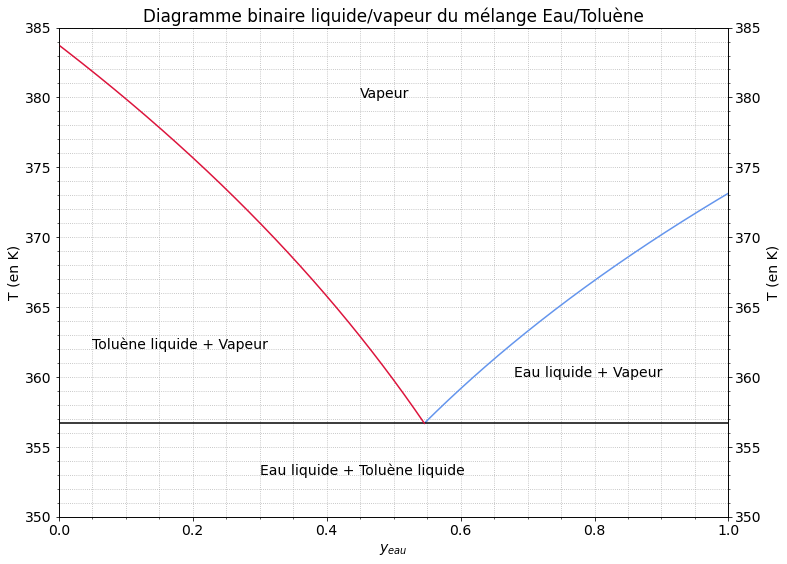

TADAAAA


In [37]:
if heteroazeotrope :
    # y_1 = resultats[0]
    # y_2 = resultats[1]
    T = resultats[-1]

    fig, ax1 = plt.subplots(figsize = (12,9))
    ax2 = ax1.twinx()
    

    ax1.plot(y_1[indice_y0:], T[indice_y0:], c = 'cornflowerblue') 
    ax2.plot(1 - y_2[indice_y0:] , T[indice_y0:], c = 'crimson') 
    ax1.plot(np.zeros(len(y_1)) + T_heteroazeotrope, 'k') # Tracer de l'horizontale, la courbe d'ébulition
    
    ax1.grid(which = 'both', ls = ':')
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.set_xlim(0,1)
    ax1.set_ylim(350,385)
    ax2.set_ylim(350,385)
    ax1.set_xlabel(r'$y_{eau}$')
    ax1.set_ylabel('T (en K)')
    ax2.set_ylabel('T (en K)')
    ax1.set_title("Diagramme binaire liquide/vapeur du mélange Eau/Toluène")
    
    ax1.text(0.3, 353, 'Eau liquide + Toluène liquide')
    ax1.text(0.05, 362, 'Toluène liquide + Vapeur')
    ax1.text(0.68, 360, 'Eau liquide + Vapeur')
    ax1.text(0.45, 380, 'Vapeur')
    
    plt.show()
    
    print('TADAAAA')